# Lab 2: Linear Regression

#Objective of the Lab

* To understand and apply the complete Machine Learning pipeline using Linear Regression.
* To predict salary based on years of experience using a Simple Linear Regression model.
* To train and evaluate a regression model using appropriate performance metrics.
* To understand the role of data preprocessing, model training, and evaluation in machine learning.

#Linear Regression

Linear Regression is a supervised machine learning algorithm used to predict a continuous numerical value by modeling the relationship between an input feature and a target variable. It assumes a linear relationship between the independent variable (YearsExperience) and the dependent variable (Salary).

The linear regression equation is:

y = mx + c

where:

y = Predicted Salary

x = Years of Experience

m = Slope (coefficient)

c = Intercept

The model learns the values of the slope and intercept from the training data and uses them to make predictions. The performance of the model is evaluated using Mean Squared Error (MSE), which measures the average squared difference between actual and predicted values. A lower MSE indicates better model performance. The R² Score may also be used to measure how well the model explains the variability in the target variable.

Linear Regression is widely used because it is simple, interpretable, computationally efficient, and effective when a linear relationship exists between variables.

#Mean Squared Error (MSE)

Mean Squared Error (MSE) is a loss function used in Linear Regression to measure the average squared difference between the actual values and the predicted values. It helps evaluate how well the model fits the data. A lower MSE value indicates better model performance, as the predictions are closer to the actual values.

MSE = (1/n) Σ(yᵢ - ŷᵢ)²

Where:

n = Number of observations

yᵢ = Actual value

ŷᵢ = Predicted value

A smaller MSE indicates that the predicted values are closer to the actual values.

Advantages of Linear Regression:

* Simple and easy to implement.

* Easy to interpret and visualize.

* Computationally efficient.

* Works well when variables have a linear relationship.


#Simple Linear Regression

Simple Linear Regression is a supervised machine learning algorithm used to predict a continuous numerical value based on a single independent variable. It establishes a linear relationship between the input feature and the target variable by fitting the best possible straight line through the data points.

The objective of Simple Linear Regression is to find the line that minimizes the prediction error between the actual and predicted values. The relationship between the variables is represented by the equation:

y = b₀ + b₁x

where:

* y = dependent variable (target)

* x = independent variable (feature)

* b₀ = intercept

* b₁ = coefficient (slope)

In this lab, Simple Linear Regression is used to predict employee salary based on years of experience. The model learns how salary changes with experience and uses this relationship to make predictions for new data.


In [5]:
# dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets

#Data Retrieval and Collection

The first step in the Machine Learning pipeline is to collect and load the dataset into the working environment. The dataset contains observations of input features and corresponding target values. After loading the dataset, its shape and column names are examined to understand the number of records and available attributes. This helps in gaining an initial understanding of the data before further processing.


In [7]:
df = pd.read_csv("Salary_Data.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

df.head()
df.describe()

Shape: (30, 2)

Columns:
Index(['YearsExperience', 'Salary'], dtype='str')


,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


#Data Cleaning

Data cleaning ensures that the dataset is accurate and suitable for model training. Missing values are identified and handled appropriately to prevent errors during learning. Data types are verified to ensure that numerical features are stored as numeric values. Clean data improves the reliability and performance of the machine learning model.


In [9]:
print("Missing Values:")
print(df.isnull().sum())
print("\nData Types:")
print(df.dtypes)

Missing Values:
YearsExperience    0
Salary             0
dtype: int64

Data Types:
YearsExperience    float64
Salary               int64
dtype: object


#Feature Design

Feature design involves separating the independent variables (features) from the dependent variable (target). The features are used by the model to make predictions, while the target variable represents the value that the model aims to predict. Proper feature selection is important because it directly affects model performance.


In [11]:
X = df[['YearsExperience']]
y = df['Salary']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (30, 1)
Target Shape: (30,)


#Algorithm Selection

Linear Regression is selected because the target variable is continuous and numerical. The algorithm models the relationship between input features and the target variable using a linear equation. It is simple, interpretable, and widely used as a baseline regression technique.

#why linear regression is appropriate for this task?

Linear Regression is appropriate for this task because the target variable, Salary, is a continuous numerical value. The dataset aims to predict salary based on years of experience, and there is generally a positive linear relationship between these variables. Linear Regression can effectively model this relationship and provide interpretable predictions.

In [12]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

#Model Learning (Training)

The dataset is divided into training and testing sets. The training set is used to learn the relationship between input features and the target variable. During training, Linear Regression estimates the coefficients and intercept that minimize the Mean Squared Error between actual and predicted values.
This helps detect overfitting and provides a realistic estimate of the model's performance.



In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 25321.583011776813
Coefficients: [9423.81532303]


#Loss Function Selection

Mean Squared Error (MSE) is used as the loss function for evaluating regression models. MSE measures the average squared difference between actual and predicted values. Lower MSE values indicate better model performance because the predictions are closer to the true values.

Formula:

MSE = (1/n) Σ(yi - ŷi)²


In [15]:

from sklearn.metrics import mean_squared_error


y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 49830096.85590839


#what MSE measures?

Mean Squared Error (MSE) measures the average squared difference between the actual values and the predicted values. It indicates how close the model's predictions are to the true values. A lower MSE means better model performance, as the prediction errors are smaller.

#Model Evaluation

Model evaluation measures how well the trained model performs on unseen data. Mean Squared Error (MSE) quantifies prediction error, while the R² Score measures the proportion of variance explained by the model. A lower MSE and a higher R² score indicate better predictive performance.


In [16]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R² Score:", r2)

MSE: 49830096.85590839
R² Score: 0.9024461774180497


The model achieved an MSE of 49,830,096.86 and an R² Score of 0.9024. The R² value indicates that approximately 90.24% of the variation in salary can be explained by years of experience, showing a strong linear relationship between the variables. Although the MSE is relatively large due to the scale of salary values, the high R² Score suggests that the Linear Regression model fits the data well and provides accurate salary predictions.

#Visualize the Regression Line

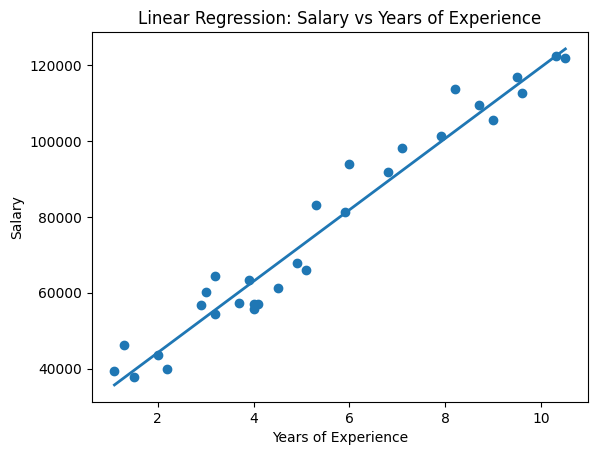

In [17]:
import matplotlib.pyplot as plt

plt.scatter(X, y)
plt.plot(X, model.predict(X), linewidth=2)

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Linear Regression: Salary vs Years of Experience")

plt.show()


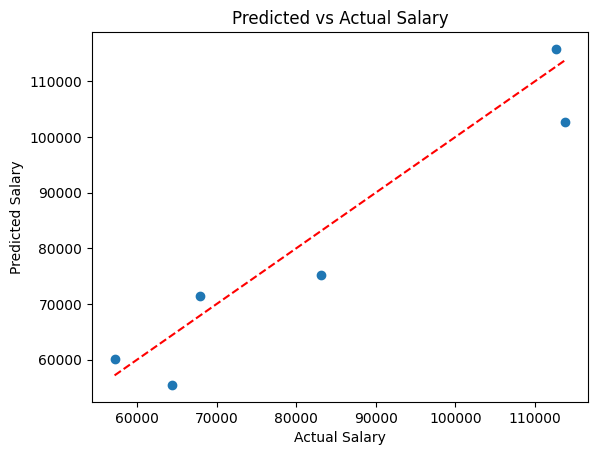

In [19]:
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Predicted vs Actual Salary")
plt.show()

#Linear Regression is based on several assumptions:

Linearity – There should be a linear relationship between the independent and dependent variables.
Independence – Observations should be independent of one another.
Homoscedasticity – The variance of residuals should remain constant across all levels of the independent variable.
Normality of Residuals – Residuals (errors) should be approximately normally distributed.
No Multicollinearity – Independent variables should not be highly correlated with each other (important when multiple features are used).

For the Salary dataset, the relationship between YearsExperience and Salary appears approximately linear, making Linear Regression a suitable choice for prediction.

In [20]:
print("Coefficient (Slope):", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient (Slope): 9423.815323030976
Intercept: 25321.583011776813


#Model Interpretation

#Coefficient (Slope)

The coefficient (slope) of the model is 9423.82. This means that for every additional year of experience, the predicted salary increases by approximately 9423.82 units. The positive coefficient indicates a positive relationship between years of experience and salary.

#Intercept

The intercept of the model is 25321.58. This represents the predicted salary when an employee has 0 years of experience. According to the model, a person with no experience is expected to earn approximately 25321.58 units.

#Regression Equation

Based on the learned parameters, the regression equation is:

Salary= 25321.58 + 9423.82(YearsExperience)

#Interpretation of the Equation

The equation shows that salary increases linearly with years of experience. The model predicts a starting salary of 25321.58 and an increase of approximately 9423.82 in salary for each additional year of experience. This confirms that experience is a significant factor in determining salary in the given dataset.

#Discussion

In this lab, a Linear Regression model was trained to predict employee salaries based on years of experience. The model learned a positive relationship between the two variables, with a coefficient (slope) of 9423.82, indicating that salary increases by approximately 9423.82 units for each additional year of experience. The intercept value of 25321.58 represents the estimated starting salary for an employee with no experience. The model achieved an R² Score of 0.9024, which means that approximately 90.24% of the variation in salary is explained by years of experience. The Mean Squared Error (MSE) of 49,830,096.86 indicates the average squared prediction error. The high R² score suggests that the model fits the data well and can make reliable salary predictions.

#Conclusion

This lab successfully demonstrated the complete Machine Learning pipeline using Linear Regression for salary prediction. The dataset was collected, cleaned, and prepared before training the model. The model learned the relationship between years of experience and salary and was able to make predictions effectively. The evaluation results and visualizations indicated that the model captured the underlying trend in the data and provided reliable predictions. Overall, the experiment showed that Linear Regression is a simple, interpretable, and effective technique for predicting continuous numerical values such as employee salaries.